# Python·SQL 기반 국가 온실가스 배출구조 분석
### 제조업 중심 데이터 기반 감축 검토 대상 도출

## 프로젝트 개요

1990~2023년 국가 온실가스 인벤토리 데이터를 활용해
국내 온실가스 배출구조의 장기적인 변화를 분석했다.

Python과 Pandas를 이용해 원본 데이터를 전처리하고,
전처리한 데이터를 MySQL에 저장한 뒤 SQL을 활용해
분야별 배출량, 증감률, 감소 기여도를 분석했다.

이후 국가 전체에서 에너지 분야,
에너지산업과 세부 배출원까지 단계적으로 분석 범위를 좁혔다.

또한 제조업 및 건설업은 세부 업종별 배출 규모와
2018~2023년 변화 방향을 비교해
추가적인 감축 검토가 필요한 업종을 데이터 기준으로 분류했다.

### 핵심 분석 질문

1. 1990~2023년 국가 온실가스 배출량은 어떻게 변했는가?
2. 2018년 이후 총배출량 감소에 어떤 분야가 크게 기여했는가?
3. 에너지 분야 내부에서는 어떤 세부 분야의 변화가 컸는가?
4. 제조업에서 배출 규모가 크면서 최근 증가하고 있는 업종은 어디인가?

### 사용 기술

- Python
- Pandas
- Matplotlib
- MySQL
- SQL
- SQLAlchemy
- PyMySQL
- Jupyter Notebook
- PyCharm

In [2]:
# 데이터 분석, 시각화, MySQL 연결에 필요한 라이브러리를 불러오기 위한 코드

import pandas as pd
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, text, URL
from getpass import getpass
from pathlib import Path

In [3]:
# 국가 온실가스 인벤토리 데이터를 불러오고
# 분석하기 쉬운 Long Format으로 변환하기 위한 코드

file_path = "../data/raw/national_ghg_inventory.csv"

df = pd.read_csv(
    file_path,
    encoding="utf-8-sig",
    keep_default_na=False
)

long_df = df.melt(
    id_vars="분야 및 연도",
    var_name="연도",
    value_name="배출량_원본"
)

# 배출량 중 숫자로 변환 가능한 값만 분석용 수치로 변환
long_df["배출량"] = pd.to_numeric(
    long_df["배출량_원본"],
    errors="coerce"
)

# 연도를 숫자형으로 변환
long_df["연도"] = long_df["연도"].astype(int)

# 숫자와 원본 표기기호를 구분하기 위한 상태 컬럼 생성
long_df["상태"] = long_df["배출량_원본"].where(
    long_df["배출량"].isna(),
    "수치"
)

# 실제 빈칸을 별도로 구분
long_df.loc[
    long_df["배출량_원본"] == "",
    "상태"
] = "빈칸"

# 표기기호의 쉼표 형식을 통일
long_df["상태"] = long_df["상태"].str.replace(
    r"\s*,\s*",
    ", ",
    regex=True
)

print("원본 데이터:", df.shape)
print("Long Format:", long_df.shape)

long_df.head()

원본 데이터: (162, 35)
Long Format: (5508, 5)


,분야 및 연도,연도,배출량_원본,배출량,상태
0,총배출량(kt CO2-eq),1990,310565.51,310565.51,수치
1,순배출량,1990,271459.59,271459.59,수치
2,에너지,1990,234518,234518.00,수치
3,A 연료연소,1990,223523.85,223523.85,수치
4,A 연료연소_1 에너지산업,1990,42004.07,42004.07,수치


## 1. 데이터 전처리

원본 데이터는 1990~2023년이 각각 열로 구성된 Wide Format이기 때문에
연도를 하나의 변수로 활용할 수 있도록 Long Format으로 변환했다.

또한 배출량 컬럼에는 실제 수치뿐 아니라
NO, NA, IE, NE, C 등의 온실가스 인벤토리 표기값이 포함되어 있다.

따라서 원본 표기값은 `배출량_원본`에 그대로 보존하고,
숫자로 변환 가능한 값만 `배출량` 컬럼으로 분리해 분석에 사용했다.

이 과정에서 표기기호를 임의로 0으로 처리하거나 삭제하지 않았다.

In [4]:
# 계층형 데이터의 중복집계를 피하기 위해
# 국가 배출구조 분석에 필요한 주요 분야만 추출하기 위한 코드

main_categories = [
    "총배출량(kt CO2-eq)",
    "순배출량",
    "에너지",
    "산업공정 및 제품사용",
    "농업",
    "LULUCF",
    "폐기물"
]

main_df = long_df[
    long_df["분야 및 연도"].isin(main_categories)
].copy()

main_df.head(10)

,분야 및 연도,연도,배출량_원본,배출량,상태
0,총배출량(kt CO2-eq),1990,310565.51,310565.51,수치
1,순배출량,1990,271459.59,271459.59,수치
2,에너지,1990,234518,234518.00,수치
43,산업공정 및 제품사용,1990,37807.9,37807.90,수치
88,농업,1990,24800.27,24800.27,수치
115,LULUCF,1990,-39105.93,-39105.93,수치
140,폐기물,1990,13439.35,13439.35,수치
162,총배출량(kt CO2-eq),1991,341226.26,341226.26,수치
163,순배출량,1991,306083.96,306083.96,수치
164,에너지,1991,257373.99,257373.99,수치


## 2. 국가 온실가스 배출구조 분석

원본 인벤토리에는 상위 분야와 세부 분야가 함께 포함되어 있다.

예를 들어 `에너지` 배출량 안에는
에너지산업, 제조업 및 건설업, 수송 등의 세부 항목이 포함되어 있기 때문에
모든 행의 배출량을 단순 합산하면 중복집계가 발생할 수 있다.

따라서 국가 전체 배출구조를 분석할 때는
총배출량, 순배출량, 에너지, 산업공정 및 제품사용,
농업, LULUCF, 폐기물만 별도로 추출해 사용했다.



In [5]:
# 1990~2023년 국가 총배출량의 장기 변화를
# 분석하기 위해 총배출량 데이터만 추출하기 위한 코드

total_df = main_df[
    main_df["분야 및 연도"] == "총배출량(kt CO2-eq)"
][["연도", "배출량"]].copy()

total_df.head()

,연도,배출량
0,1990,310565.51
162,1991,341226.26
324,1992,368799.41
486,1993,403692.61
648,1994,432772.12


In [6]:
# 국가 총배출량의 시작값, 최근값, 최고점을
# 한 번에 확인하기 위한 코드

start_emission = total_df.loc[
    total_df["연도"] == 1990,
    "배출량"
].iloc[0]

latest_emission = total_df.loc[
    total_df["연도"] == 2023,
    "배출량"
].iloc[0]

peak_row = total_df.loc[
    total_df["배출량"].idxmax()
]

long_term_change = (
    latest_emission
    -
    start_emission
)

long_term_rate = (
    long_term_change
    /
    start_emission
    * 100
)

print(f"1990년 총배출량: {start_emission:,.2f} kt CO2-eq")
print(f"2023년 총배출량: {latest_emission:,.2f} kt CO2-eq")
print(f"장기 증감량: {long_term_change:,.2f} kt CO2-eq")
print(f"장기 증감률: {long_term_rate:.2f}%")
print(
    f"최고 배출량: {int(peak_row['연도'])}년 "
    f"{peak_row['배출량']:,.2f} kt CO2-eq"
)

1990년 총배출량: 310,565.51 kt CO2-eq
2023년 총배출량: 707,199.78 kt CO2-eq
장기 증감량: 396,634.27 kt CO2-eq
장기 증감률: 127.71%
최고 배출량: 2018년 780,140.33 kt CO2-eq


In [8]:
# Matplotlib 그래프에서 한글이 깨지지 않도록
# Windows 기본 한글 폰트인 맑은 고딕을 설정하기 위한 코드

plt.rcParams["font.family"] = "Malgun Gothic"

# 그래프에서 음수 기호(-)가 깨지는 것을 방지
plt.rcParams["axes.unicode_minus"] = False

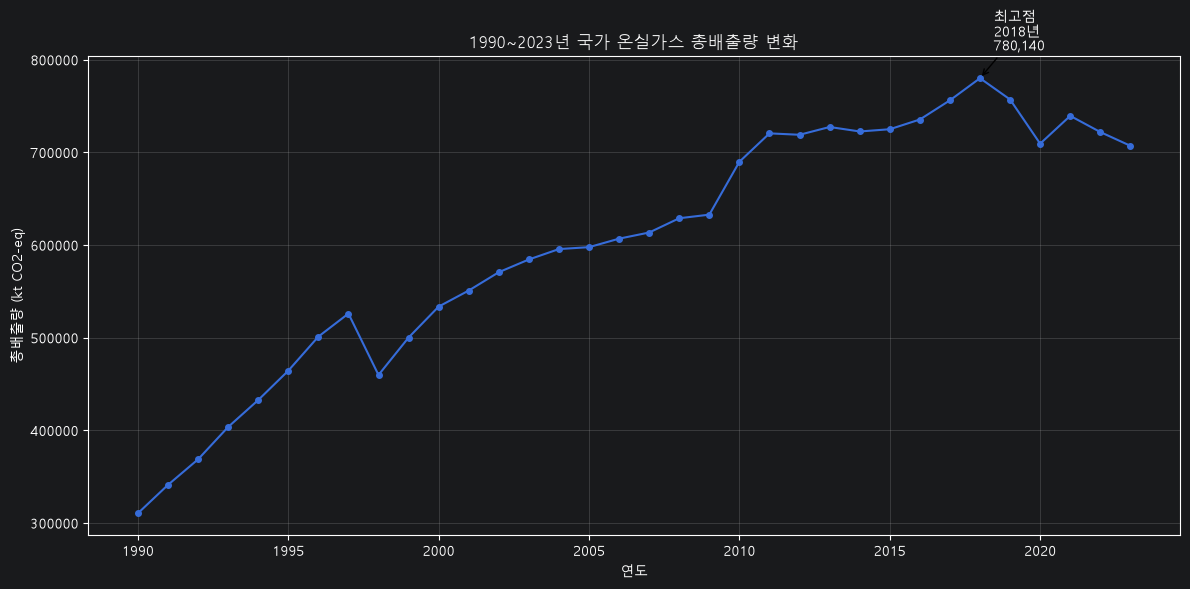

In [9]:
# 1990~2023년 국가 총배출량 변화와
# 최고 배출 시점을 시각화하기 위한 코드

plt.figure(figsize=(12, 6))

plt.plot(
    total_df["연도"],
    total_df["배출량"],
    marker="o",
    markersize=4
)

plt.annotate(
    f'최고점\n{int(peak_row["연도"])}년\n'
    f'{peak_row["배출량"]:,.0f}',
    xy=(
        peak_row["연도"],
        peak_row["배출량"]
    ),
    xytext=(10, 20),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->"}
)

plt.xlabel("연도")
plt.ylabel("총배출량 (kt CO2-eq)")
plt.title("1990~2023년 국가 온실가스 총배출량 변화")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [10]:
# 2023년 국가 총배출량에서
# 주요 배출 분야가 차지하는 비중을 계산하기 위한 코드

sectors = [
    "에너지",
    "산업공정 및 제품사용",
    "농업",
    "폐기물"
]

sector_2023 = main_df[
    (main_df["연도"] == 2023)
    &
    (main_df["분야 및 연도"].isin(sectors))
][["분야 및 연도", "배출량"]].copy()

total_2023 = total_df.loc[
    total_df["연도"] == 2023,
    "배출량"
].iloc[0]

sector_2023["비중(%)"] = (
    sector_2023["배출량"]
    /
    total_2023
    * 100
)

sector_2023["비중(%)"] = sector_2023["비중(%)"].round(2)

sector_2023 = sector_2023.sort_values(
    "배출량",
    ascending=False
)

sector_2023

,분야 및 연도,배출량,비중(%)
5348,에너지,544988.30,77.06
5389,산업공정 및 제품사용,121502.15,17.18
5434,농업,22537.34,3.19
5486,폐기물,18172.00,2.57


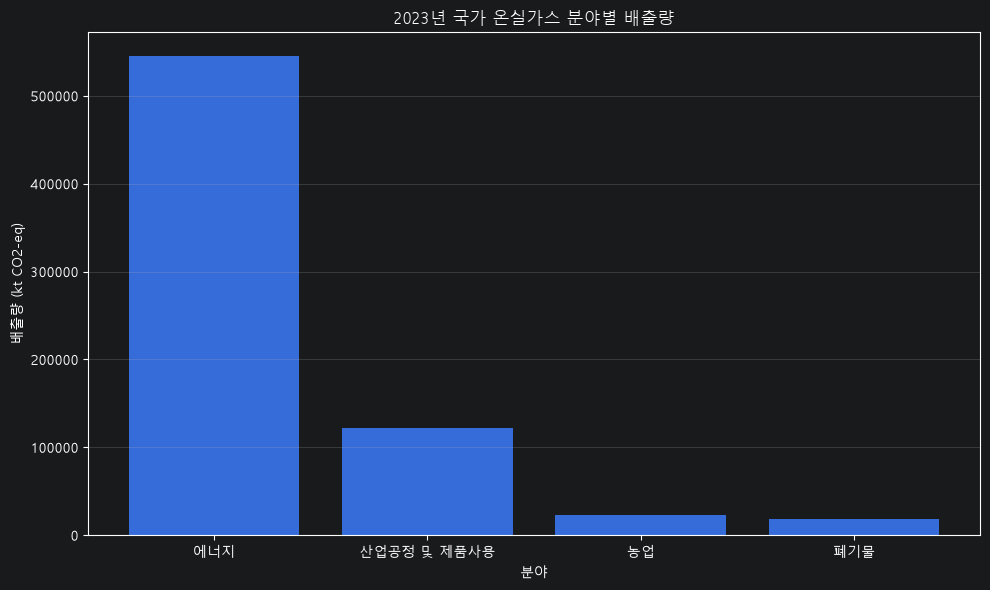

In [11]:
# 2023년 주요 분야별 배출량 규모를
# 막대그래프로 비교하기 위한 코드

plt.figure(figsize=(10, 6))

plt.bar(
    sector_2023["분야 및 연도"],
    sector_2023["배출량"]
)

plt.xlabel("분야")
plt.ylabel("배출량 (kt CO2-eq)")
plt.title("2023년 국가 온실가스 분야별 배출량")

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 2-2. 2023년 분야별 배출구조

2023년 국가 온실가스 총배출량 중
에너지 분야가 약 77.1%로 가장 큰 비중을 차지했다.

산업공정 및 제품사용은 약 17.2%였으며,
농업과 폐기물은 각각 약 3.2%, 2.6% 수준으로 나타났다.

이를 통해 현재 국가 온실가스 배출구조에서
에너지 분야의 영향이 가장 크다는 것을 확인했다.

다음 단계에서는 국가 총배출량이 최고점을 기록한 2018년과
2023년을 비교해 최근 배출량 감소에
각 분야가 얼마나 기여했는지 분석한다.

## 3. SQL 기반 최근 배출 감소 기여 구조 분석

Pandas에서 전처리한 데이터를 MySQL에 저장한 뒤
SQL을 이용해 2018년과 2023년의 주요 분야별 배출량을 비교했다.

2018년은 분석 기간 중 국가 총배출량이 가장 높았던 시점이므로,
2023년과 비교해 최근 국가 배출량 감소가
어느 분야에서 주로 나타났는지 확인했다.

이 분석에서는 단순한 증감률뿐만 아니라
국가 전체 감소량에서 각 분야의 감소량이 차지하는 비중을
`감소기여도`로 계산했다.

In [12]:
# 비밀번호를 코드에 직접 저장하지 않고 입력받아
# 프로젝트용 MySQL 데이터베이스에 연결하기 위한 코드

mysql_password = getpass(
    "ghg_user 비밀번호를 입력하세요: "
)

db_url = URL.create(
    drivername="mysql+pymysql",
    username="ghg_user",
    password=mysql_password,
    host="localhost",
    port=3306,
    database="ghg_project",
    query={"charset": "utf8mb4"}
)

engine = create_engine(db_url)

In [13]:
# Pandas에서 전처리한 long_df 데이터를
# MySQL의 ghg_inventory 테이블에 저장하기 위한 코드

long_df.to_sql(
    name="ghg_inventory",
    con=engine,
    if_exists="replace",
    index=False,
    chunksize=1000
)

print("ghg_inventory 테이블 저장 완료")

ghg_inventory 테이블 저장 완료


In [14]:
# SQL을 사용해 2018년과 2023년의 주요 분야별 배출량을 비교하고
# 국가 총배출량 감소에서 각 분야가 차지하는 감소 기여도를 계산하기 위한 코드

sql_recent_change = pd.read_sql(
    text("""
        SELECT
            `분야 및 연도` AS `분야`,

            MAX(
                IF(`연도` = 2018, `배출량`, NULL)
            ) AS `2018년 배출량`,

            MAX(
                IF(`연도` = 2023, `배출량`, NULL)
            ) AS `2023년 배출량`,

            ROUND(
                MAX(IF(`연도` = 2023, `배출량`, NULL))
                -
                MAX(IF(`연도` = 2018, `배출량`, NULL)),
                2
            ) AS `증감량`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 2018, `배출량`, NULL))
                )
                /
                NULLIF(
                    MAX(IF(`연도` = 2018, `배출량`, NULL)),
                    0
                )
                * 100,
                2
            ) AS `증감률(%)`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 2018, `배출량`, NULL))
                )
                /
                (
                    (
                        SELECT `배출량`
                        FROM `ghg_inventory`
                        WHERE `연도` = 2023
                          AND `분야 및 연도` = '총배출량(kt CO2-eq)'
                    )
                    -
                    (
                        SELECT `배출량`
                        FROM `ghg_inventory`
                        WHERE `연도` = 2018
                          AND `분야 및 연도` = '총배출량(kt CO2-eq)'
                    )
                )
                * 100,
                2
            ) AS `감소기여도(%)`

        FROM `ghg_inventory`

        WHERE `분야 및 연도` IN (
            '에너지',
            '산업공정 및 제품사용',
            '농업',
            '폐기물'
        )

        GROUP BY `분야 및 연도`

        ORDER BY `감소기여도(%)` DESC;
    """),
    engine
)

sql_recent_change

,분야,2018년 배출량,2023년 배출량,증감량,증감률(%),감소기여도(%)
0,에너지,613672.85,544988.30,-68684.55,-11.19,94.17
1,산업공정 및 제품사용,123823.34,121502.15,-2321.19,-1.87,3.18
2,폐기물,19336.59,18172.00,-1164.59,-6.02,1.60
3,농업,23307.54,22537.34,-770.20,-3.30,1.06


### 3-1. 2018~2023년 분야별 감소 기여 구조

2018년과 2023년을 비교한 결과
에너지, 산업공정 및 제품사용, 농업, 폐기물 모두
배출량이 감소했다.

이 중 에너지 분야는 약 68,685 kt CO2-eq 감소했으며,
국가 총배출량 감소분의 약 94.2%를 차지했다.

산업공정 및 제품사용의 감소 기여도는 약 3.2%,
폐기물은 약 1.6%, 농업은 약 1.1%로 나타났다.

따라서 최근 국가 총배출량 감소는
주요 분야 중 에너지 분야의 감소와 가장 크게 연결되어 있었다.

다음 단계에서는 에너지 분야 내부로 분석 범위를 좁혀
어떤 세부 분야의 감소가 크게 나타났는지 확인한다.

In [16]:
# SQL을 사용해 2018년과 2023년의 에너지 세부 분야별 배출량을 비교하고
# 에너지 전체 감소량에서 각 세부 분야가 차지하는 감소 기여도를 계산하기 위한 코드

sql_energy_detail = pd.read_sql(
    text("""
        SELECT
            `분야 및 연도` AS `세부분야`,

            MAX(
                IF(`연도` = 2018, `배출량`, NULL)
            ) AS `2018년 배출량`,

            MAX(
                IF(`연도` = 2023, `배출량`, NULL)
            ) AS `2023년 배출량`,

            ROUND(
                MAX(IF(`연도` = 2023, `배출량`, NULL))
                -
                MAX(IF(`연도` = 2018, `배출량`, NULL)),
                2
            ) AS `증감량`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 2018, `배출량`, NULL))
                )
                /
                NULLIF(
                    MAX(IF(`연도` = 2018, `배출량`, NULL)),
                    0
                )
                * 100,
                2
            ) AS `증감률(%)`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 2018, `배출량`, NULL))
                )
                /
                NULLIF(
                    (
                        SELECT `배출량`
                        FROM `ghg_inventory`
                        WHERE `연도` = 2023
                          AND `분야 및 연도` = '에너지'
                    )
                    -
                    (
                        SELECT `배출량`
                        FROM `ghg_inventory`
                        WHERE `연도` = 2018
                          AND `분야 및 연도` = '에너지'
                    ),
                    0
                )
                * 100,
                2
            ) AS `감소기여도(%)`

        FROM `ghg_inventory`

        WHERE `연도` IN (2018, 2023)
          AND `분야 및 연도` IN (
              'A 연료연소_1 에너지산업',
              'A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업',
              'A 연료연소_3 수송',
              'A 연료연소_4 기타',
              'A 연료연소_5 미분류',
              'B 탈루'
          )

        GROUP BY `분야 및 연도`

        ORDER BY `감소기여도(%)` DESC;
    """),
    engine
)

sql_energy_detail

,세부분야,2018년 배출량,2023년 배출량,증감량,증감률(%),감소기여도(%)
0,A 연료연소_1 에너지산업,297732.94,248155.39,-49577.55,-16.65,72.18
1,A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업,157209.46,147240.38,-9969.08,-6.34,14.51
2,A 연료연소_4 기타,53012.02,45502.68,-7509.34,-14.17,10.93
3,A 연료연소_3 수송,98882.39,97825.94,-1056.45,-1.07,1.54
4,B 탈루,3687.98,3241.99,-445.99,-12.09,0.65
5,A 연료연소_5 미분류,3148.07,3021.92,-126.15,-4.01,0.18


### 3-2. 에너지 분야 세부 감소 기여 구조

2018~2023년 에너지 분야의 배출량 감소를
세부 분야별로 분석했다.

에너지산업의 감소 기여도가 약 72.2%로 가장 높았으며,
제조업 및 건설업은 약 14.5%,
기타 분야는 약 10.9%를 차지했다.

수송, 탈루, 미분류 분야의 감소 기여도는
상대적으로 낮게 나타났다.

따라서 최근 에너지 분야의 배출량 감소는
에너지산업의 변화와 가장 크게 연결되어 있었다.

다음 단계에서는 에너지산업 내부로 한 단계 더 내려가
공공 전기 및 열 생산, 석유정제 등
세부 배출원의 변화를 확인한다.

In [17]:
# SQL을 사용해 에너지산업 세부 분야의 2018년과 2023년 배출량을 비교하고
# 에너지산업 전체 감소량에서 각 세부 분야가 차지하는 기여도를 계산하기 위한 코드

sql_energy_industry = pd.read_sql(
    text("""
        SELECT
            `분야 및 연도` AS `세부분야`,

            MAX(
                IF(`연도` = 2018, `배출량`, NULL)
            ) AS `2018년 배출량`,

            MAX(
                IF(`연도` = 2023, `배출량`, NULL)
            ) AS `2023년 배출량`,

            ROUND(
                MAX(IF(`연도` = 2023, `배출량`, NULL))
                -
                MAX(IF(`연도` = 2018, `배출량`, NULL)),
                2
            ) AS `증감량`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 2018, `배출량`, NULL))
                )
                /
                NULLIF(
                    MAX(IF(`연도` = 2018, `배출량`, NULL)),
                    0
                )
                * 100,
                2
            ) AS `증감률(%)`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 2018, `배출량`, NULL))
                )
                /
                NULLIF(
                    (
                        SELECT `배출량`
                        FROM `ghg_inventory`
                        WHERE `연도` = 2023
                          AND `분야 및 연도` = 'A 연료연소_1 에너지산업'
                    )
                    -
                    (
                        SELECT `배출량`
                        FROM `ghg_inventory`
                        WHERE `연도` = 2018
                          AND `분야 및 연도` = 'A 연료연소_1 에너지산업'
                    ),
                    0
                )
                * 100,
                2
            ) AS `감소기여도(%)`

        FROM `ghg_inventory`

        WHERE `연도` IN (2018, 2023)
          AND `분야 및 연도` IN (
              'A 연료연소_a 공공 전기 및 열 생산',
              'A 연료연소_b 석유정제',
              'A 연료연소_c 고체연료 제조 및 기타 에너지 산업'
          )

        GROUP BY `분야 및 연도`

        ORDER BY `감소기여도(%)` DESC;
    """),
    engine
)

sql_energy_industry

,세부분야,2018년 배출량,2023년 배출량,증감량,증감률(%),감소기여도(%)
0,A 연료연소_a 공공 전기 및 열 생산,276618.81,226959.86,-49658.95,-17.95,100.16
1,A 연료연소_b 석유정제,20289.29,19605.15,-684.14,-3.37,1.38
2,A 연료연소_c 고체연료 제조 및 기타 에너지 산업,824.84,1590.37,765.53,92.81,-1.54


### 3-3. 에너지산업 세부 감소 기여 구조

에너지 분야 감소에 가장 크게 기여한 에너지산업을
세부 분야별로 나누어 분석했다.

공공 전기 및 열 생산은
2018년 약 276,619 kt CO2-eq에서
2023년 약 226,960 kt CO2-eq로 감소했다.

감소량은 약 49,659 kt CO2-eq로,
에너지산업 세부 분야 중 가장 큰 감소폭을 보였다.

석유정제도 소폭 감소했지만,
고체연료 제조 및 기타 에너지 산업은 오히려 배출량이 증가했다.

공공 전기 및 열 생산의 감소 기여도는 약 100.2%로 나타났다.

100%를 넘은 이유는
공공 전기 및 열 생산의 감소분 일부가
고체연료 제조 및 기타 에너지 산업의 증가로 상쇄되었기 때문이다.

따라서 2018~2023년 에너지산업 배출 감소는
주로 공공 전기 및 열 생산 부문의 감소와 연결되어 있었다.



In [18]:
# SQL을 사용해 제조업 및 건설업 세부 업종의
# 2018년과 2023년 배출량, 증감률, 2023년 배출 비중을 계산하기 위한 코드

sql_manufacturing = pd.read_sql(
    text("""
        SELECT
            `분야 및 연도` AS `세부분야`,

            MAX(
                IF(`연도` = 2018, `배출량`, NULL)
            ) AS `2018년 배출량`,

            MAX(
                IF(`연도` = 2023, `배출량`, NULL)
            ) AS `2023년 배출량`,

            ROUND(
                MAX(IF(`연도` = 2023, `배출량`, NULL))
                -
                MAX(IF(`연도` = 2018, `배출량`, NULL)),
                2
            ) AS `증감량`,

            ROUND(
                (
                    MAX(IF(`연도` = 2023, `배출량`, NULL))
                    -
                    MAX(IF(`연도` = 2018, `배출량`, NULL))
                )
                /
                NULLIF(
                    MAX(IF(`연도` = 2018, `배출량`, NULL)),
                    0
                )
                * 100,
                2
            ) AS `증감률(%)`,

            ROUND(
                MAX(IF(`연도` = 2023, `배출량`, NULL))
                /
                (
                    SELECT `배출량`
                    FROM `ghg_inventory`
                    WHERE `연도` = 2023
                      AND `분야 및 연도`
                          = 'A 연료연소_2 제조업 및 건설업_2 제조업 및 건설업'
                )
                * 100,
                2
            ) AS `2023년 비중(%)`

        FROM `ghg_inventory`

        WHERE `연도` IN (2018, 2023)
          AND `분야 및 연도` IN (
              'A 연료연소_a 철강',
              'A 연료연소_b 비철금속',
              'A 연료연소_c 화학',
              'A 연료연소_d 펄프, 제지 및 인쇄',
              'A 연료연소_e 식음료품 가공 및 담배 제조',
              'A 연료연소_f 비금속광물',
              'A 연료연소_g 기타'
          )

        GROUP BY `분야 및 연도`

        ORDER BY `2023년 배출량` DESC;
    """),
    engine
)

sql_manufacturing

,세부분야,2018년 배출량,2023년 배출량,증감량,증감률(%),2023년 비중(%)
0,A 연료연소_a 철강,83663.20,74997.26,-8665.94,-10.36,50.94
1,A 연료연소_c 화학,23795.11,24925.76,1130.65,4.75,16.93
2,A 연료연소_g 기타,28677.37,23293.66,-5383.71,-18.77,15.82
3,A 연료연소_f 비금속광물,13684.83,15432.97,1748.14,12.77,10.48
4,A 연료연소_b 비철금속,2927.06,3775.43,848.37,28.98,2.56
5,"A 연료연소_d 펄프, 제지 및 인쇄",2291.56,2750.24,458.68,20.02,1.87
6,A 연료연소_e 식음료품 가공 및 담배 제조,2170.33,2065.05,-105.28,-4.85,1.40


## 4. 제조업 및 건설업 세부 업종 분석

에너지 분야에서 감소 규모가 컸던
제조업 및 건설업을 세부 업종별로 분석했다.

2023년 기준 철강은 제조업 및 건설업 배출량의
약 50.9%를 차지해 가장 큰 배출 규모를 보였다.

하지만 철강은 2018년 대비 배출량이 약 10.4% 감소했다.

반면 화학은 약 4.8%,
비금속광물은 약 12.8% 증가했다.

비철금속과 펄프·제지 및 인쇄도 증가율은 높았지만,
현재 배출 규모는 상대적으로 작았다.

따라서 감축 검토 대상을 선정할 때
현재 배출량의 절대적인 규모뿐 아니라
최근 배출량의 증가 방향도 함께 고려할 필요가 있다고 판단했다.

In [19]:
# 제조업 세부 업종의 현재 배출 규모와 최근 증감 방향을 이용해
# 1차 감축 검토 우선도 점수를 계산하기 위한 코드

priority_df = sql_manufacturing.copy()

# 그래프와 결과표에서 보기 쉽게 업종명 정리
priority_df["업종"] = priority_df["세부분야"].str.replace(
    r"^A 연료연소_[a-g] ",
    "",
    regex=True
)

# 2023년 업종별 배출량의 중앙값 계산
median_emission = priority_df["2023년 배출량"].median()

# 배출량이 중앙값 이상이면 규모점수 2점
priority_df["규모점수"] = (
    priority_df["2023년 배출량"] >= median_emission
).astype(int) * 2

# 2018년보다 2023년 배출량이 증가했으면 증가점수 1점
priority_df["증가점수"] = (
    priority_df["증감량"] > 0
).astype(int)

# 두 점수를 합산
priority_df["검토점수"] = (
    priority_df["규모점수"]
    +
    priority_df["증가점수"]
)

print(f"2023년 배출량 중앙값: {median_emission:,.2f} kt CO2-eq")

2023년 배출량 중앙값: 15,432.97 kt CO2-eq


In [20]:
# 계산한 검토점수를 1순위부터 4순위까지
# 1차 감축 검토 우선도로 변환하기 위한 코드

priority_df["검토우선도"] = priority_df["검토점수"].map({
    3: "1순위",
    2: "2순위",
    1: "3순위",
    0: "4순위"
})

priority_df = priority_df.sort_values(
    by=["검토점수", "2023년 배출량"],
    ascending=[False, False]
)

priority_df[
    [
        "업종",
        "2023년 배출량",
        "증감량",
        "증감률(%)",
        "규모점수",
        "증가점수",
        "검토점수",
        "검토우선도"
    ]
]

,업종,2023년 배출량,증감량,증감률(%),규모점수,증가점수,검토점수,검토우선도
1,화학,24925.76,1130.65,4.75,2,1,3,1순위
3,비금속광물,15432.97,1748.14,12.77,2,1,3,1순위
0,철강,74997.26,-8665.94,-10.36,2,0,2,2순위
2,기타,23293.66,-5383.71,-18.77,2,0,2,2순위
4,비철금속,3775.43,848.37,28.98,0,1,1,3순위
5,"펄프, 제지 및 인쇄",2750.24,458.68,20.02,0,1,1,3순위
6,식음료품 가공 및 담배 제조,2065.05,-105.28,-4.85,0,0,0,4순위


## 5. 제조업 세부 업종 1차 감축 검토 우선도

제조업 세부 업종을 대상으로
현재 배출 규모와 최근 배출량 변화 방향을 함께 비교했다.

2023년 업종별 배출량이 중앙값 이상이면 규모점수 2점,
2018년보다 2023년 배출량이 증가했다면 증가점수 1점을 부여했다.

분석 결과 화학과 비금속광물은
현재 배출 규모가 일정 수준 이상이면서
최근 배출량도 증가해 가장 높은 검토점수를 받았다.

철강은 제조업 중 가장 큰 배출 규모를 가지고 있지만
2018년 이후 배출량이 감소해 두 번째 그룹으로 분류됐다.

다만 이 결과는 배출 규모와 최근 증가 여부만을 이용한
1차적인 데이터 기반 스크리닝이다.

실제 감축 정책이나 기업의 투자 우선순위를 결정하기 위해서는
감축 비용, 기술 적용 가능성, 생산량, 에너지 사용량,
규제 수준 등의 추가적인 요소를 함께 고려해야 한다.

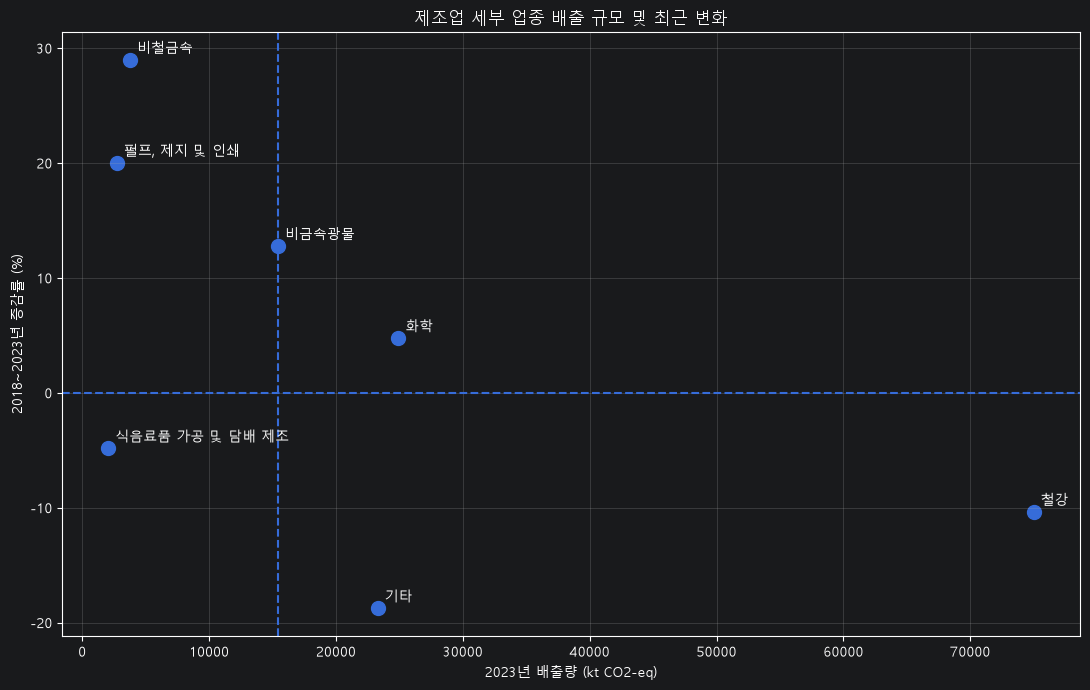

In [21]:
# 제조업 세부 업종의 2023년 배출 규모와 최근 증감률을
# 산점도로 시각화하기 위한 코드

plt.figure(figsize=(11, 7))

plt.scatter(
    priority_df["2023년 배출량"],
    priority_df["증감률(%)"],
    s=100
)

# 2023년 배출량 중앙값 기준선
plt.axvline(
    x=median_emission,
    linestyle="--"
)

# 증감률 0% 기준선
plt.axhline(
    y=0,
    linestyle="--"
)

# 각 점에 업종명 표시
for _, row in priority_df.iterrows():
    plt.annotate(
        row["업종"],
        (
            row["2023년 배출량"],
            row["증감률(%)"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("2023년 배출량 (kt CO2-eq)")
plt.ylabel("2018~2023년 증감률 (%)")
plt.title("제조업 세부 업종 배출 규모 및 최근 변화")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### 6-1. 제조업 세부 업종 배출 특성 시각화

2023년 배출량을 X축,
2018~2023년 배출량 증감률을 Y축으로 설정해
제조업 세부 업종의 배출 특성을 비교했다.

세로 기준선은 2023년 업종별 배출량의 중앙값이며,
가로 기준선은 증감률 0%를 의미한다.

화학과 비금속광물은
배출 규모가 중앙값 이상이면서 최근 배출량도 증가해
오른쪽 위 영역에 위치했다.

반면 철강은 제조업 중 가장 큰 배출 규모를 보였지만
2018년 이후 배출량이 감소해 오른쪽 아래 영역에 위치했다.

이를 통해 배출량의 절대적인 규모만 보는 것이 아니라
현재 배출 규모와 최근 변화 방향을 함께 비교해
추가적인 감축 검토가 필요한 업종을 구분했다.

In [22]:
# 지금까지 분석한 핵심 결과를 가져와
# 최종 분석 요약표를 만들기 위한 코드

energy_contribution = sql_recent_change.loc[
    sql_recent_change["분야"] == "에너지",
    "감소기여도(%)"
].iloc[0]

energy_industry_contribution = sql_energy_detail.loc[
    sql_energy_detail["세부분야"] == "A 연료연소_1 에너지산업",
    "감소기여도(%)"
].iloc[0]

power_contribution = sql_energy_industry.loc[
    sql_energy_industry["세부분야"]
    == "A 연료연소_a 공공 전기 및 열 생산",
    "감소기여도(%)"
].iloc[0]

priority_1 = priority_df.loc[
    priority_df["검토우선도"] == "1순위",
    "업종"
].tolist()

final_summary = pd.DataFrame({
    "분석단계": [
        "국가 전체",
        "에너지 분야",
        "에너지산업",
        "제조업 및 건설업"
    ],

    "핵심결과": [
        f"2018~2023년 국가 배출량 감소의 {energy_contribution:.2f}%가 에너지 분야에서 발생",
        f"에너지 분야 감소의 {energy_industry_contribution:.2f}%가 에너지산업에서 발생",
        f"에너지산업 감소의 {power_contribution:.2f}%가 공공 전기 및 열 생산에서 발생",
        f"1차 감축 검토 대상: {', '.join(priority_1)}"
    ]
})

final_summary

,분석단계,핵심결과
0,국가 전체,2018~2023년 국가 배출량 감소의 94.17%가 에너지 분야에서 발생
1,에너지 분야,에너지 분야 감소의 72.18%가 에너지산업에서 발생
2,에너지산업,에너지산업 감소의 100.16%가 공공 전기 및 열 생산에서 발생
3,제조업 및 건설업,"1차 감축 검토 대상: 화학, 비금속광물"


## 7. 최종 분석 결과

1990~2023년 국가 온실가스 인벤토리 데이터를
Python, Pandas, MySQL, SQL을 활용해 분석했다.

### 1. 국가 온실가스 배출구조

1990년 약 310,566 kt CO2-eq였던 국가 총배출량은
2023년 약 707,200 kt CO2-eq로 증가했다.

분석 기간 중 가장 높은 배출량은 2018년에 나타났으며,
2023년 국가 총배출량의 약 77.1%는 에너지 분야에서 발생했다.

따라서 국가 온실가스 배출구조에서
에너지 분야가 가장 큰 비중을 차지하고 있음을 확인했다.

### 2. 최근 배출량 감소 기여 구조

국가 총배출량이 가장 높았던 2018년과 2023년을 비교한 결과,
국가 총배출량 감소분의 약 94.2%가
에너지 분야의 감소와 연결되어 있었다.

에너지 분야 내부에서는
에너지산업이 감소분의 약 72.2%를 차지했다.

에너지산업을 다시 세분화한 결과
공공 전기 및 열 생산 부문의 배출량 감소가
에너지산업 전체 감소에서 가장 큰 부분을 차지했다.

### 3. 제조업 세부 업종 분석

2023년 기준 철강은 제조업 및 건설업 배출량의
약 50.9%를 차지해 가장 큰 배출 규모를 보였다.

하지만 철강의 배출량은 2018년 이후 감소한 반면,
화학과 비금속광물은 최근 배출량이 증가했다.

현재 배출 규모와 최근 변화 방향을 함께 비교한 결과,
화학과 비금속광물을 1차적인 감축 검토 대상으로 분류했다.

### 4. 분석의 한계

이번 제조업 검토 우선도는
2023년 배출 규모와 2018~2023년 배출량 변화만을 이용한
1차적인 데이터 기반 스크리닝이다.

따라서 실제 기업의 환경관리 또는 감축 투자 의사결정에는
감축 비용, 기술 적용 가능성, 생산량, 에너지 사용량,
규제 수준 등의 추가적인 데이터를 함께 분석할 필요가 있다.